Imports

In [ ]:
import sys, json, time

#for google colab
sys.path.append('/content/Waste-Classification')

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef
import seaborn as sns

'''root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))'''


from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.MobileViT import MobileViT
from Pipeline_.focal_loss import FocalLoss

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128


Data Pipeline

In [ ]:
#modified due to execution in google colab
from collections import Counter
base_path = Path('/content/Waste-Classification')

pp = WaRPPreprocessor(
    raw_root       = base_path / 'Dataset/raw/Warp-C',
    processed_root = base_path / 'Dataset/processed',
    stats_file     = base_path / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 2,
    mean           = [0.0, 0.0, 0.0],
    std            = [1.0, 1.0, 1.0],
)

#added due to execution in google colab
pp.prepare(force=False)

train_loader, test_loader = pp.get_loaders(model_type='mobilevit')



  WaRPPreprocessor.prepare()

  Leakage filenames found : 18
  Minority classes        : ['bottle-blue5l-full', 'bottle-oil-full', 'detergent-box']


  Copying test: 100%|██████████| 28/28 [00:00<00:00, 127.77it/s]



  ✓ Train images    : 8767
  ✓ Test  images    : 1551
  ✓ Leakage removed : 18
  ✓ Output          : /content/Waste-Classification/Dataset/processed/
[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom


In [ ]:
class_weights = pp.get_class_weights(device=DEVICE)
#soft_weights = torch.sqrt(class_weights)  #softer version
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
#print(f'Class weights shape: {soft_weights.shape}')
#print(f'Min weight: {soft_weights.min():.3f}  Max weight: {soft_weights.max():.3f}')

In [ ]:
CLASS_NAMES = sorted(d.name for d in (base_path / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)

print(f'Classes : {NUM_CLASSES}')
print(f'Train batches plain: {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

Classes : 28
Train batches plain: 273
Test  batches : 49


In [ ]:
# Force num_workers to 0 after creation  // multiple workers made Google colab crash as it has limitations on multiprocessing
#error: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary. self.check_worker_number_rationality()
'''
train_loader.num_workers = 0
test_loader.num_workers = 0'''


'\ntrain_loader.num_workers = 0\ntest_loader.num_workers = 0'

Model - Phase 1

Training Parameters



In [ ]:
PHASE1_EPOCHS = 15
PHASE2_EPOCHS = 45
TOTAL_EPOCHS = PHASE1_EPOCHS + PHASE2_EPOCHS

PHASE1_LR = 8e-4
HEAD_LR = 8e-4
BACKBONE_LR = 8e-5

WEIGHT_DECAY_P1 = 1e-4
WEIGHT_DECAY_P2 = 1e-4

In [ ]:
#Phase 1 - freezing backbone
model = MobileViT(number_of_classes=NUM_CLASSES, freeze=True, dropout=0.2).to(DEVICE)

parameters_dict = model.model_parameter_counts()
print(f'Model parameters: {parameters_dict}')

# verifying forward pass shape
dummy_input = torch.zeros(4, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    output = model(dummy_input)
print(f'\nInput  shape : {dummy_input.shape}')
print(f'Output shape : {output.shape}   ← should be (4, {NUM_CLASSES})')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/347 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Model parameters: {'model': 'MobileViT-Small', 'total_params': 4955580, 'trainable_params': 17948, 'total_M': 4.96, 'trainable_M': 0.02}

Input  shape : torch.Size([4, 3, 224, 224])
Output shape : torch.Size([4, 28])   ← should be (4, 28)


In [ ]:
# Print all parameter groups in your model
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.shape}")

pretrained_backbone.classifier.1.weight: torch.Size([28, 640])
pretrained_backbone.classifier.1.bias: torch.Size([28])


Model Training

In [ ]:
# Phase 1 optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
    weight_decay=WEIGHT_DECAY_P1
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

In [ ]:
# Training loop with automatic phase transition

train_accs = []
train_losses = []
train_mccs = []
test_accs=[]
best_train_mcc = -1
best_test_acc = 0.0

for epoch in range(TOTAL_EPOCHS):
    if epoch == PHASE1_EPOCHS:
        print(f"🔄 SWITCHING TO PHASE 2 (Unfreezing backbone at epoch {epoch})")

        # Unfreezing the backbone
        model.unfreeze_backbone()

        #============================================
        # Separate parameters
        backbone_params = []
        head_params = []

        for name, param in model.named_parameters():
            param.requires_grad = True  # Unfreeze everything
            if 'classifier' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)
        # Create optimizer with DIFFERENTIAL learning rates
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': BACKBONE_LR, 'weight_decay': WEIGHT_DECAY_P2},
            {'params': head_params, 'lr': HEAD_LR, 'weight_decay': WEIGHT_DECAY_P2}
        ])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6
        )

        # Verify LRs
        print(f"Head LR: {optimizer.param_groups[1]['lr']}")    # Should be 8e-4
        print(f"Backbone LR: {optimizer.param_groups[0]['lr']}") # Should be 5e-5

    # Training for current epoch
    model.train()
    train_correct, train_total = 0, 0
    epoch_loss = 0
    all_train_preds = []
    all_train_labels = []

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # adding gradient clipping
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        train_total += labels.size(0)
        train_correct += pred.eq(labels).sum().item()

        all_train_preds.extend(pred.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    avg_loss = epoch_loss / train_total
    avg_train_acc = 100. * train_correct / train_total
    train_mcc = matthews_corrcoef(all_train_labels, all_train_preds)

    train_accs.append(avg_train_acc)
    train_losses.append(avg_loss)
    train_mccs.append(train_mcc)

# ==================================================
    #Evaluation
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            logits = model(images)
            preds = logits.argmax(dim=1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    avg_test_acc = 100.0 * test_correct / test_total
    test_accs.append(avg_test_acc)

    if avg_test_acc > best_test_acc:
        best_test_acc = avg_test_acc
        torch.save(model.state_dict(), 'phase1_best.pth')


    # Determine current phase for display
    current_phase = "Phase 1 (Frozen)" if epoch < PHASE1_EPOCHS else "Phase 2 (Fine-tuning)"

    print(f"Epoch {epoch+1:3d}/{TOTAL_EPOCHS} [{current_phase}] | "
          f"Train Loss: {avg_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
          f"| Test Acc: {avg_test_acc:.2f}% |"
          f"MCC: {train_mcc:.4f} | LR: {current_lr:.6f}")

print(f'\nBest test accuracy: {best_test_acc:.2f}%')


Epoch   1/60 [Phase 1 (Frozen)] | Train Loss: 3.0702 | Train Acc: 23.42% | | Test Acc: 24.69% |MCC: 0.2063 | LR: 0.000791
Epoch   2/60 [Phase 1 (Frozen)] | Train Loss: 2.7463 | Train Acc: 32.34% | | Test Acc: 27.01% |MCC: 0.3000 | LR: 0.000765
Epoch   3/60 [Phase 1 (Frozen)] | Train Loss: 2.5899 | Train Acc: 35.00% | | Test Acc: 28.95% |MCC: 0.3273 | LR: 0.000724
Epoch   4/60 [Phase 1 (Frozen)] | Train Loss: 2.5233 | Train Acc: 35.85% | | Test Acc: 29.92% |MCC: 0.3356 | LR: 0.000668
Epoch   5/60 [Phase 1 (Frozen)] | Train Loss: 2.4576 | Train Acc: 37.28% | | Test Acc: 30.11% |MCC: 0.3505 | LR: 0.000600
Epoch   6/60 [Phase 1 (Frozen)] | Train Loss: 2.4297 | Train Acc: 38.04% | | Test Acc: 31.53% |MCC: 0.3581 | LR: 0.000524
Epoch   7/60 [Phase 1 (Frozen)] | Train Loss: 2.3862 | Train Acc: 38.87% | | Test Acc: 31.66% |MCC: 0.3668 | LR: 0.000442
Epoch   8/60 [Phase 1 (Frozen)] | Train Loss: 2.3622 | Train Acc: 40.08% | | Test Acc: 31.01% |MCC: 0.3789 | LR: 0.000358
Epoch   9/60 [Phase 1 (F

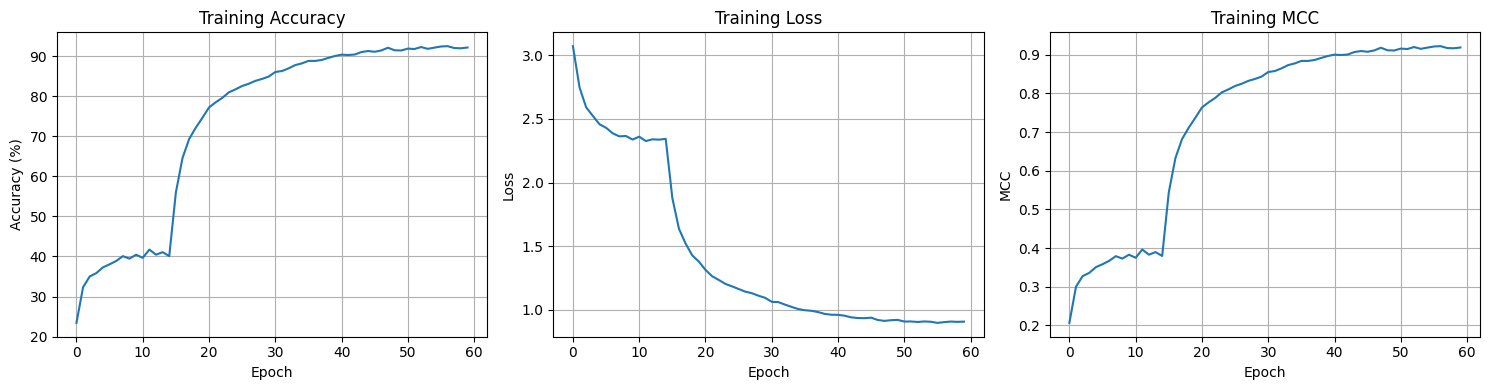

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy plot
ax1.plot(train_accs)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Training Accuracy')
ax1.grid(True)

# Loss plot
ax2.plot(train_losses)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss')
ax2.grid(True)

# MCC plot
ax3.plot(train_mccs)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('MCC')
ax3.set_title('Training MCC')
ax3.grid(True)

plt.tight_layout()
plt.show()

Evaluating on Test data

In [ ]:
model.load_state_dict(torch.load('phase1_best.pth'))
model.eval()
test_correct, test_total = 0, 0
test_loss_total = 0
all_test_preds, all_test_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss_total += loss.item()
        _, pred = outputs.max(1)
        test_total += labels.size(0)
        test_correct += pred.eq(labels).sum().item()
        all_test_preds.extend(pred.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

test_acc = 100. * test_correct / test_total
test_loss = test_loss_total / len(test_loader)
test_mcc = matthews_corrcoef(all_test_labels, all_test_preds)

all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

print("TEST RESULTS")
print(f"\nTest Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Train-Test Gap: {train_accs[-1] - test_acc:.2f}%")

TEST RESULTS

Test Accuracy: 74.85%
Test Loss: 1.3481
Test MCC: 0.7348
Train-Test Gap: 17.29%


In [ ]:
print(classification_report(all_test_labels, all_test_preds,
                             target_names=CLASS_NAMES,
                             digits=3))

                         precision    recall  f1-score   support

            bottle-blue      0.814     0.673     0.737       104
       bottle-blue-full      0.750     0.628     0.684        43
          bottle-blue5l      0.660     0.861     0.747        72
     bottle-blue5l-full      0.684     0.542     0.605        24
            bottle-dark      0.824     0.884     0.853        95
       bottle-dark-full      0.659     0.794     0.720        34
           bottle-green      0.842     0.865     0.853        74
      bottle-green-full      0.756     0.912     0.827        34
            bottle-milk      0.724     0.737     0.730        57
       bottle-milk-full      0.909     0.952     0.930        21
      bottle-multicolor      0.556     0.536     0.545        28
bottle-multicolorv-full      0.714     0.714     0.714        21
             bottle-oil      0.485     0.688     0.569        48
        bottle-oil-full      0.400     0.250     0.308         8
          bottle-transp 

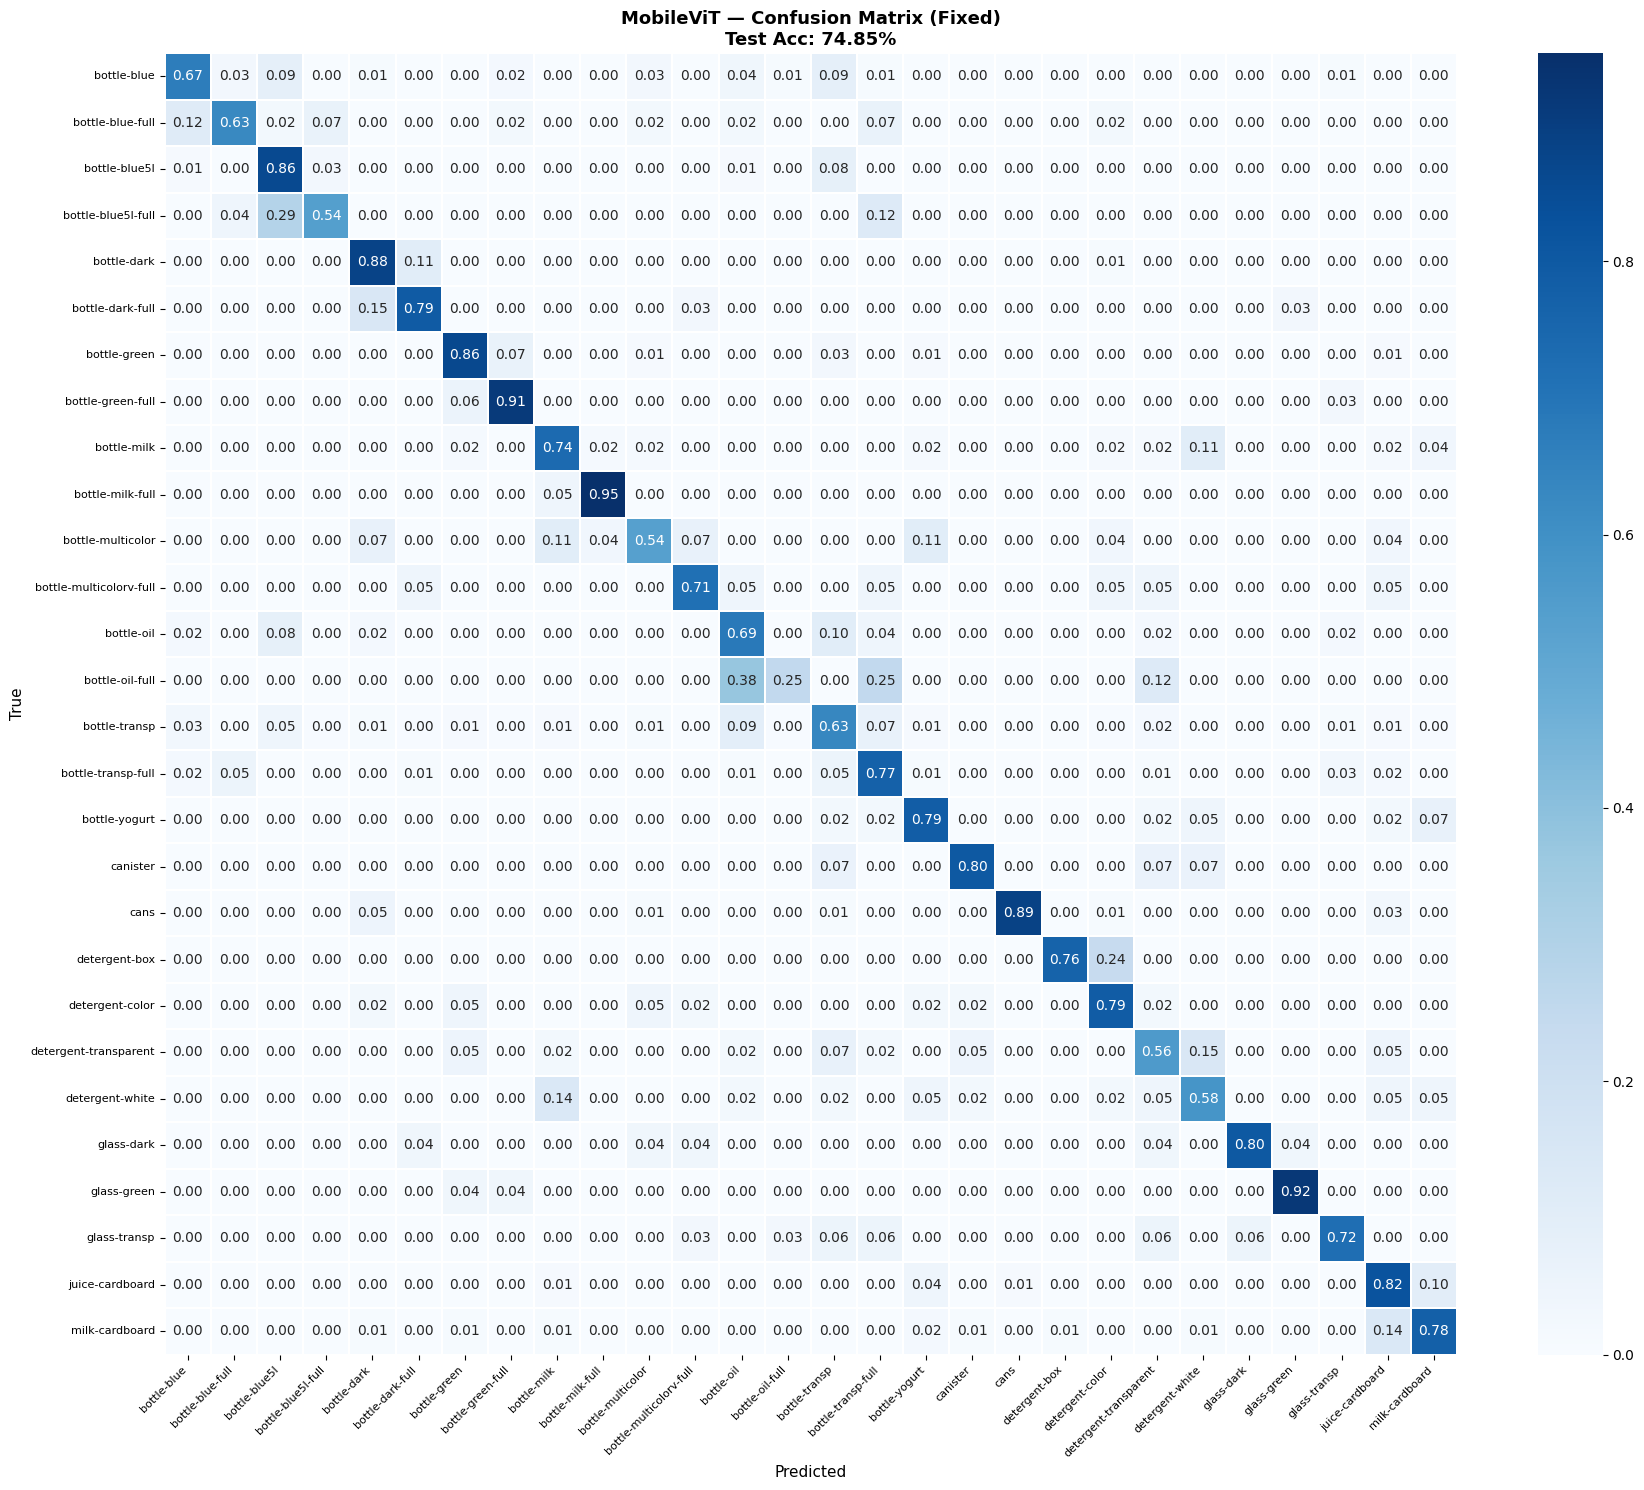

In [ ]:
cm      = confusion_matrix(all_test_labels, all_test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'MobileViT — Confusion Matrix (Fixed)\nTest Acc: {test_acc:.2f}%',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()